In [143]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    RocCurveDisplay
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DATA_PATH = Path("../data/raw/support_tickets.csv")

df = pd.read_csv(DATA_PATH)

df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("-", "_")
)

print(df.shape)
print(df.columns.tolist())
df.head()

(8469, 17)
['ticket_id', 'customer_name', 'customer_email', 'customer_age', 'customer_gender', 'product_purchased', 'date_of_purchase', 'ticket_type', 'ticket_subject', 'ticket_description', 'ticket_status', 'resolution', 'ticket_priority', 'ticket_channel', 'first_response_time', 'time_to_resolution', 'customer_satisfaction_rating']


,ticket_id,customer_name,customer_email,customer_age,customer_gender,product_purchased,date_of_purchase,ticket_type,ticket_subject,ticket_description,ticket_status,resolution,ticket_priority,ticket_channel,first_response_time,time_to_resolution,customer_satisfaction_rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0


In [144]:
text_candidates = [
    "ticket_subject",
    "subject",
    "title",
    "ticket_description",
    "description",
    "text",
    "ticket_body"
]

existing_text_cols = [col for col in text_candidates if col in df.columns]

existing_text_cols

['ticket_subject', 'ticket_description']

In [145]:
if existing_text_cols:
    df["ticket_text"] = df[existing_text_cols].fillna("").astype(str).agg(" ".join, axis=1)
else:
    df["ticket_text"] = ""

df["ticket_text"] = df["ticket_text"].fillna("").astype(str)
df["text_length"] = df["ticket_text"].str.len()
df["word_count"] = df["ticket_text"].str.split().str.len()

df[["ticket_text", "text_length", "word_count"]].head()

,ticket_text,text_length,word_count
0,Product setup I'm having an issue with the {pr...,298,45
1,Peripheral compatibility I'm having an issue w...,307,46
2,Network problem I'm facing a problem with my {...,291,44
3,Account access I'm having an issue with the {p...,277,43
4,Data loss I'm having an issue with the {produc...,343,57


In [146]:
text_lower = df["ticket_text"].str.lower()

urgent_keywords = [
    "urgent", "asap", "immediately", "critical", "blocked",
    "production", "down", "outage", "failed", "failure"
]

payment_keywords = [
    "payment", "billing", "invoice", "refund", "charge", "transaction"
]

login_keywords = [
    "login", "password", "authentication", "access", "signin", "sign in"
]

error_keywords = [
    "error", "exception", "crash", "bug", "issue", "not working", "failed"
]

df["has_urgent_keyword"] = text_lower.apply(
    lambda x: int(any(word in x for word in urgent_keywords))
)

df["has_payment_keyword"] = text_lower.apply(
    lambda x: int(any(word in x for word in payment_keywords))
)

df["has_login_keyword"] = text_lower.apply(
    lambda x: int(any(word in x for word in login_keywords))
)

df["has_error_keyword"] = text_lower.apply(
    lambda x: int(any(word in x for word in error_keywords))
)

df[[
    "has_urgent_keyword",
    "has_payment_keyword",
    "has_login_keyword",
    "has_error_keyword"
]].head()

,has_urgent_keyword,has_payment_keyword,has_login_keyword,has_error_keyword
0,0,1,0,1
1,0,0,0,1
2,0,1,0,0
3,0,0,1,1
4,0,0,0,1


In [147]:
n = len(df)

df["customer_tier"] = np.random.choice(
    ["free", "standard", "premium", "enterprise"],
    size=n,
    p=[0.35, 0.35, 0.20, 0.10]
)

df["ticket_channel"] = np.random.choice(
    ["email", "chat", "phone", "web"],
    size=n,
    p=[0.45, 0.30, 0.15, 0.10]
)

df["affected_users"] = np.random.choice(
    [1, 5, 10, 25, 50, 100, 250, 500],
    size=n,
    p=[0.25, 0.20, 0.15, 0.12, 0.10, 0.08, 0.06, 0.04]
)

df["previous_tickets_count"] = np.random.poisson(lam=2, size=n)
df["created_hour"] = np.random.randint(0, 24, size=n)

df[[
    "customer_tier",
    "ticket_channel",
    "affected_users",
    "previous_tickets_count",
    "created_hour"
]].head()

,customer_tier,ticket_channel,affected_users,previous_tickets_count,created_hour
0,standard,email,100,3,0
1,enterprise,email,10,2,14
2,premium,email,50,1,15
3,standard,email,1,7,9
4,free,email,5,1,19


In [148]:
tier_score = df["customer_tier"].map({
    "free": 0.0,
    "standard": 0.3,
    "premium": 0.7,
    "enterprise": 1.2
})

channel_score = df["ticket_channel"].map({
    "email": 0.0,
    "web": 0.1,
    "chat": 0.2,
    "phone": 0.5
})

affected_users_score = np.log1p(df["affected_users"]) / 3
previous_tickets_score = np.log1p(df["previous_tickets_count"]) / 2

raw_score = (
    -2.2
    + tier_score
    + channel_score
    + affected_users_score
    + previous_tickets_score
    + 1.0 * df["has_urgent_keyword"]
    + 0.7 * df["has_error_keyword"]
    + 0.5 * df["has_payment_keyword"]
)

# Convert raw score to probability using sigmoid
df["escalation_probability_true"] = 1 / (1 + np.exp(-raw_score))

# Sample actual escalation from probability
df["is_escalated"] = np.random.binomial(
    1,
    df["escalation_probability_true"]
)

df["is_escalated"].value_counts(normalize=True) * 100

is_escalated
1    60.786397
0    39.213603
Name: proportion, dtype: float64

In [149]:
features = [
    "customer_tier",
    "ticket_channel",
    "affected_users",
    "previous_tickets_count",
    "created_hour",
    "text_length",
    "word_count",
    "has_urgent_keyword",
    "has_payment_keyword",
    "has_login_keyword",
    "has_error_keyword"
]

target = "is_escalated"

X = df[features]
y = df[target]

X.head()

,customer_tier,ticket_channel,affected_users,previous_tickets_count,created_hour,text_length,word_count,has_urgent_keyword,has_payment_keyword,has_login_keyword,has_error_keyword
0,standard,email,100,3,0,298,45,0,1,0,1
1,enterprise,email,10,2,14,307,46,0,0,0,1
2,premium,email,50,1,15,291,44,0,1,0,0
3,standard,email,1,7,9,277,43,0,0,1,1
4,free,email,5,1,19,343,57,0,0,0,1


In [150]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

X_train.shape, X_test.shape

((6775, 11), (1694, 11))

In [151]:
numeric_features = [
    "affected_users",
    "previous_tickets_count",
    "created_hour",
    "text_length",
    "word_count",
    "has_urgent_keyword",
    "has_payment_keyword",
    "has_login_keyword",
    "has_error_keyword"
]

categorical_features = [
    "customer_tier",
    "ticket_channel"
]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

logistic_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ))
])

logistic_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [152]:
y_pred = logistic_model.predict(X_test)
y_proba = logistic_model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.6068476977567887
Precision: 0.7297979797979798
Recall: 0.5611650485436893
F1: 0.6344676180021954
ROC-AUC: 0.6649271844660194

Classification Report:
              precision    recall  f1-score   support

           0       0.50      0.68      0.57       664
           1       0.73      0.56      0.63      1030

    accuracy                           0.61      1694
   macro avg       0.61      0.62      0.60      1694
weighted avg       0.64      0.61      0.61      1694



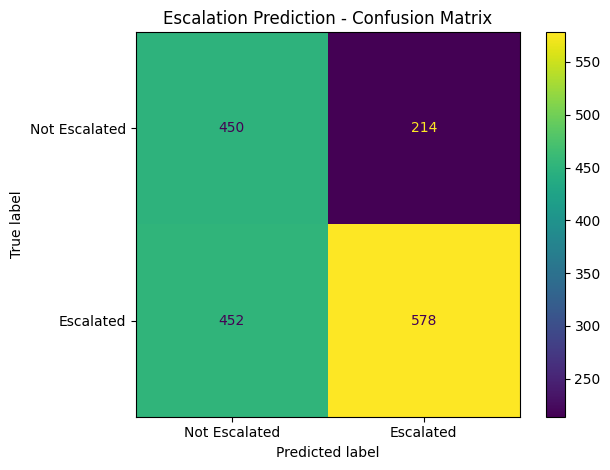

In [153]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["Not Escalated", "Escalated"]
)

plt.title("Escalation Prediction - Confusion Matrix")
plt.tight_layout()
plt.show()

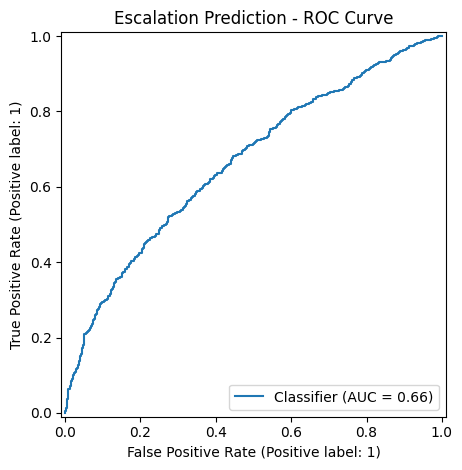

In [154]:
RocCurveDisplay.from_predictions(y_test, y_proba)
plt.title("Escalation Prediction - ROC Curve")
plt.tight_layout()
plt.show()

In [155]:
thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]

threshold_results = []

for threshold in thresholds:
    custom_pred = (y_proba >= threshold).astype(int)
    
    threshold_results.append({
        "threshold": threshold,
        "precision": precision_score(y_test, custom_pred),
        "recall": recall_score(y_test, custom_pred),
        "f1": f1_score(y_test, custom_pred)
    })

threshold_df = pd.DataFrame(threshold_results)
threshold_df

,threshold,precision,recall,f1
0,0.3,0.622057,0.974757,0.759455
1,0.4,0.670409,0.811650,0.734300
2,0.5,0.729798,0.561165,0.634468
3,0.6,0.803738,0.333981,0.471879
4,0.7,0.851282,0.161165,0.271020


In [156]:
trained_preprocessor = logistic_model.named_steps["preprocessor"]
trained_model = logistic_model.named_steps["model"]

feature_names = trained_preprocessor.get_feature_names_out()
coefficients = trained_model.coef_[0]

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients
}).sort_values("coefficient", ascending=False)

coef_df

,feature,coefficient
9,cat__customer_tier_enterprise,0.597964
0,num__affected_users,0.444354
1,num__previous_tickets_count,0.254761
11,cat__customer_tier_premium,0.233612
15,cat__ticket_channel_phone,0.226557
5,num__has_urgent_keyword,0.225458
6,num__has_payment_keyword,0.150540
8,num__has_error_keyword,0.109785
13,cat__ticket_channel_chat,0.101098
2,num__created_hour,0.050947


In [157]:
import joblib

MODEL_PATH = Path("../models/escalation_model.pkl")
MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)

joblib.dump(logistic_model, MODEL_PATH)

print(f"Model saved to {MODEL_PATH}")

Model saved to ..\models\escalation_model.pkl


In [158]:
loaded_model = joblib.load(MODEL_PATH)

sample = X_test.head(1)
loaded_model.predict(sample), loaded_model.predict_proba(sample)

(array([0], dtype=int32), array([[0.62574857, 0.37425143]]))

In [159]:
processed_path = Path("../data/processed/tickets_with_escalation.csv")
processed_path.parent.mkdir(parents=True, exist_ok=True)

df.to_csv(processed_path, index=False)

processed_path

WindowsPath('../data/processed/tickets_with_escalation.csv')